# Rydberg vapor-cell response: a field-to-spectrum chain for RF electrometry

A Rydberg-atom RF electrometer reads a microwave field's amplitude off
an atom's own energy levels. A conventional receiver reads that
amplitude off an antenna's induced voltage. A coupling laser and
an RF source split an electromagnetically induced transparency (EIT)
window that a probe laser sees in a vapor cell, and the splitting scales
linearly with the RF field, an SI-traceable measurement chain with no
external calibration. Groups building these sensors each hand-roll the
same downstream chain: a field over the cell's atom region, each atom's
own Rydberg-level response to that field, and the resulting EIT/Autler-
Townes (AT) spectrum. This notebook builds that chain for Rb-85's
5S1/2-5P3/2-32D5/2-33P3/2 ladder (E43/E44, `docs/CONVENTIONS.md` section
19), reproduces the published calibration data behind it, and composes
many atoms across an uneven field into one observed line, the same
shift-and-broadening signature a real vapor cell's own surface charge
produces and a still-open problem in the field.


In [1]:
%matplotlib inline
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd().parent / "src"))

import cliffordclock.integrator.rydberg_cell_response as rcr

plt.rcParams["figure.figsize"] = (8, 4.5)

## 1. The ladder scheme

Four atomic levels do the work. A probe laser (780.24 nm) drives the
ground state to the first excited state; a coupling laser (481.75 nm)
drives that state to the Rydberg state 32D5/2; an RF field at 68.64 GHz
couples 32D5/2 to a neighboring Rydberg state, 33P3/2. The probe laser's
transmission through the vapor cell is what a detector measures. With
the coupling laser on and the RF field off, a transparency window opens
inside the probe's ordinary absorption line (EIT). Turning the RF field
on couples in a fourth level and splits that window into two peaks
(Autler-Townes splitting), separated by an amount set by the RF field's
strength.


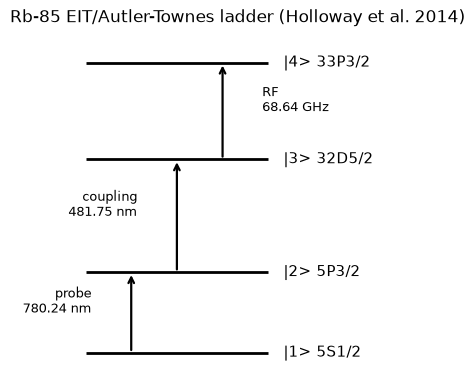

In [2]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
levels_y = [0.0, 1.0, 2.4, 3.6]
labels = ["|1> 5S1/2", "|2> 5P3/2", "|3> 32D5/2", "|4> 33P3/2"]
for y, label in zip(levels_y, labels, strict=True):
    ax.hlines(y, 0.2, 0.8, color="black", linewidth=2)
    ax.text(0.85, y, label, va="center", fontsize=11)

arrow_kwargs = dict(arrowprops=dict(arrowstyle="->", lw=1.6))
ax.annotate("", xy=(0.35, levels_y[1]), xytext=(0.35, levels_y[0]), **arrow_kwargs)
ax.text(0.22, 0.5, "probe\n780.24 nm", fontsize=9, ha="right")
ax.annotate("", xy=(0.5, levels_y[2]), xytext=(0.5, levels_y[1]), **arrow_kwargs)
ax.text(0.37, 1.7, "coupling\n481.75 nm", fontsize=9, ha="right")
ax.annotate("", xy=(0.65, levels_y[3]), xytext=(0.65, levels_y[2]), **arrow_kwargs)
ax.text(0.78, 3.0, "RF\n68.64 GHz", fontsize=9, ha="left")

ax.set_xlim(0, 1.4)
ax.set_ylim(-0.3, 4.0)
ax.axis("off")
ax.set_title("Rb-85 EIT/Autler-Townes ladder (Holloway et al. 2014)")
plt.show()

## 2. A single atom's quadratic Stark shift (E43)

A static or slowly varying field does not couple 32D5/2 to 33P3/2 the
way the RF field does. Instead it shifts the 32D5/2 level's own energy,
through the ordinary quadratic Stark effect, `Delta_f = -(alpha0/2) E^2
/ h`. `alpha0` is not itself a published number for 32D5/2 (Holloway et
al. 2014's calibration state); it comes from a power-law fit through the
three Rb-85 nD5/2 states two independent sources (O'Sullivan and
Stoicheff's measurement, Yerokhin et al.'s theory) do publish, n = 30,
35, 50.


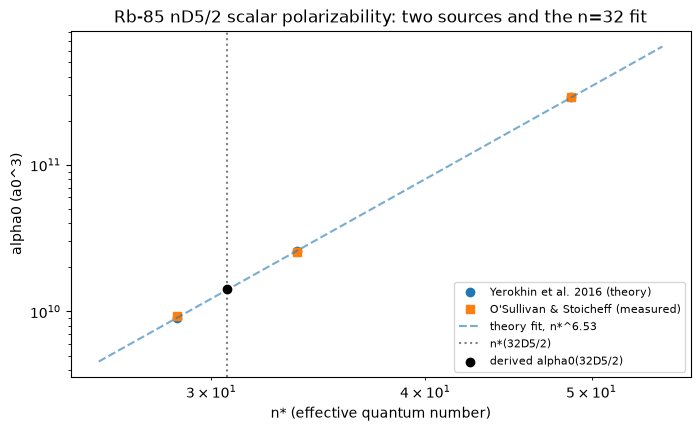

**alpha0(32D5/2), derived:** 1.4146e+10 a0^3  
**k, the O'Sullivan-Stoicheff-convention coefficient:** -1.7600 MHz/(V/cm)^2

In [3]:
rows = []
for n in (30, 35, 50):
    theory = rcr.RB85_ND52_ALPHA0_TABULATED["theory"][n].alpha0_au
    experiment = rcr.RB85_ND52_ALPHA0_TABULATED["experiment"][n].alpha0_au
    n_star = rcr.effective_quantum_number(n, rcr.RB85_ND52_QUANTUM_DEFECT)
    rows.append((n, n_star, theory, experiment))

n_star_32 = rcr.effective_quantum_number(32, rcr.RB85_ND52_QUANTUM_DEFECT)

fig, ax = plt.subplots()
n_stars = [r[1] for r in rows]
ax.loglog(
    n_stars, [r[2] for r in rows], "o", label="Yerokhin et al. 2016 (theory)", color="tab:blue"
)
ax.loglog(
    n_stars,
    [r[3] for r in rows],
    "s",
    label="O'Sullivan & Stoicheff (measured)",
    color="tab:orange",
)
n_fit = np.linspace(min(n_stars) * 0.9, 55, 200)
c_th, p_th = rcr._fit_alpha0_power_law("theory")
ax.loglog(
    n_fit, c_th * n_fit**p_th, "--", color="tab:blue", alpha=0.6, label=f"theory fit, n*^{p_th:.2f}"
)
ax.axvline(n_star_32, color="gray", linestyle=":", label="n*(32D5/2)")
ax.scatter(
    [n_star_32], [rcr.RB85_32D52_ALPHA0_AU], color="black", zorder=5, label="derived alpha0(32D5/2)"
)
ax.set_xlabel("n* (effective quantum number)")
ax.set_ylabel("alpha0 (a0^3)")
ax.legend(fontsize=8)
ax.set_title("Rb-85 nD5/2 scalar polarizability: two sources and the n=32 fit")
plt.show()

display(
    Markdown(
        f"**alpha0(32D5/2), derived:** {rcr.RB85_32D52_ALPHA0_AU:.4e} a0^3  \n"
        f"**k, the O'Sullivan-Stoicheff-convention coefficient:** "
        f"{rcr.alpha0_au_to_mhz_per_vcm2(rcr.RB85_32D52_ALPHA0_AU):.4f} MHz/(V/cm)^2"
    )
)

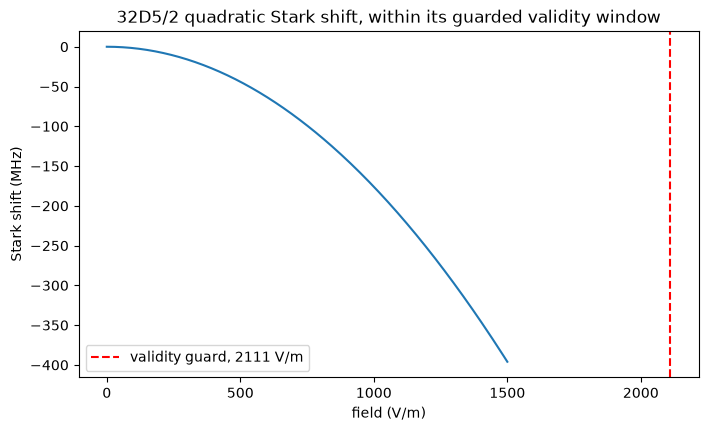

In [4]:
n_star = n_star_32
fields = np.linspace(0.0, 1500.0, 300)
shifts_mhz = [
    rcr.rydberg_quadratic_stark_shift_hz(rcr.RB85_32D52_ALPHA0_AU, f, n_star) / 1e6 for f in fields
]

fig, ax = plt.subplots()
ax.plot(fields, shifts_mhz)
guard = rcr.STARK_VALIDITY_MARGIN * rcr.inglis_teller_field_v_per_m(n_star)
ax.axvline(guard, color="red", linestyle="--", label=f"validity guard, {guard:.0f} V/m")
ax.set_xlabel("field (V/m)")
ax.set_ylabel("Stark shift (MHz)")
ax.legend()
ax.set_title("32D5/2 quadratic Stark shift, within its guarded validity window")
plt.show()

## 3. The EIT/Autler-Townes spectrum, Doppler-averaged (E44)

`ladder_susceptibility` transcribes Holloway et al. 2014's own Eqs.
(1)-(4). Setting the RF field to zero collapses it to a plain EIT dip;
turning the RF field on splits that dip into the Autler-Townes doublet.
`doppler_averaged_susceptibility` folds in the thermal vapor's velocity
spread, following Mohapatra et al. 2007's own velocity-resolved
susceptibility structure.


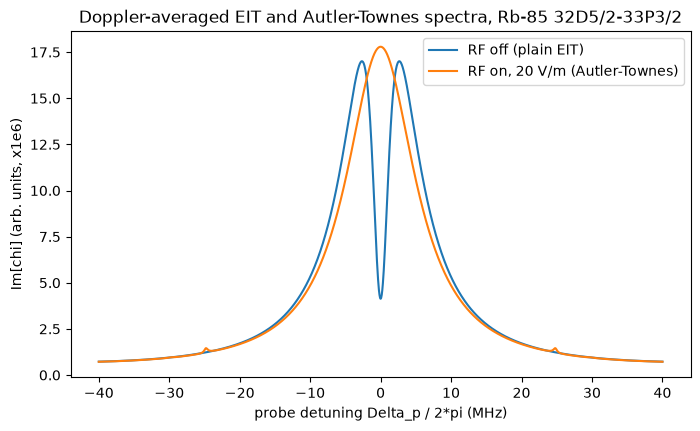

In [5]:
system = rcr.LadderSystem(
    mu_probe_c_m=2.0e-29,
    mu_coupling_c_m=5.0e-30,
    mu_rf_c_m=rcr.RB85_MU_RF_32D52_33P32_C_M,
    gamma_12=2.0 * math.pi * 6.0e6,
    gamma_13=2.0 * math.pi * 0.3e6,
    gamma_14=2.0 * math.pi * 0.3e6,
    number_density_m3=1.0e16,
    wavelength_probe_m=rcr.HOLLOWAY_LAMBDA_PROBE_M,
    wavelength_coupling_m=rcr.HOLLOWAY_LAMBDA_COUPLING_M,
)

delta_p = np.linspace(-2.0 * math.pi * 40e6, 2.0 * math.pi * 40e6, 2001)
e_coupling = 662.0  # V/m: Omega_c/2pi ~= 5 MHz, comparable to gamma_12/2pi

spec_no_rf = rcr.doppler_averaged_susceptibility(
    delta_p, 0.0, 0.0, 1.0, e_coupling, 0.0, system, 320.0, rcr.RB85_MASS_KG
)
spec_rf = rcr.doppler_averaged_susceptibility(
    delta_p, 0.0, 0.0, 1.0, e_coupling, 20.0, system, 320.0, rcr.RB85_MASS_KG
)

fig, ax = plt.subplots()
ax.plot(delta_p / (2 * math.pi) / 1e6, spec_no_rf.imag * 1e6, label="RF off (plain EIT)")
ax.plot(delta_p / (2 * math.pi) / 1e6, spec_rf.imag * 1e6, label="RF on, 20 V/m (Autler-Townes)")
ax.set_xlabel("probe detuning Delta_p / 2*pi (MHz)")
ax.set_ylabel("Im[chi] (arb. units, x1e6)")
ax.legend()
ax.set_title("Doppler-averaged EIT and Autler-Townes spectra, Rb-85 32D5/2-33P3/2")
plt.show()

## 4. The Doppler-mismatch factor: a real conflict in the literature, resolved

The Autler-Townes splitting seen in this probe-detuning spectrum is not
the bare Rabi splitting `Omega_RF/2*pi`: it is rescaled by the probe and
coupling wavelengths. Two published sources (Holloway et al. 2014,
Mohapatra et al. 2007) state a REDUCTION factor, `lambda_c/lambda_p`; a
third (Sedlacek et al. 2012) states the prose reciprocal,
`lambda_p/lambda_c`, an enhancement. `docs/CONVENTIONS.md` section 19
derives the observed splitting from the ladder's own Doppler-detuning
geometry directly, independent of either paper's stated direction, and
the derivation lands on the reduction factor, matching Holloway and
Mohapatra. The cell below reproduces that check numerically: it extracts
the Autler-Townes doublet spacing straight from the Doppler-averaged
spectrum above and compares it against the closed-form
`(lambda_c/lambda_p) * Omega_RF/(2*pi)` prediction.


In [6]:
from scipy.signal import find_peaks

field_check = 20.0
analytic_split_hz = rcr.autler_townes_splitting_hz(
    system.mu_rf_c_m, field_check, system.wavelength_probe_m, system.wavelength_coupling_m
)
# A window matched to the expected splitting and a finer grid than section 3's
# illustrative plot resolves the two Autler-Townes peaks cleanly (the same
# parameters `tests/test_rydberg_cell_response.py`'s C7 check validates).
window_hz = 1.5 * analytic_split_hz
delta_p_check = np.linspace(-2 * math.pi * window_hz, 2 * math.pi * window_hz, 12001)
spec_check = rcr.doppler_averaged_susceptibility(
    delta_p_check,
    0.0,
    0.0,
    1.0,
    e_coupling,
    field_check,
    system,
    320.0,
    rcr.RB85_MASS_KG,
    n_velocity_points=89,
)
im = spec_check.imag
peaks, props = find_peaks(im, prominence=np.max(im) * 0.02)
order = np.argsort(-props["prominences"])[:2]
idxs = sorted(peaks[order])
numeric_split_hz = (delta_p_check[idxs[1]] - delta_p_check[idxs[0]]) / (2 * math.pi)

analytic_split_mhz = analytic_split_hz / 1e6
numeric_split_mhz = numeric_split_hz / 1e6
split_ratio = numeric_split_hz / analytic_split_hz

display(
    Markdown(
        f"**Closed-form splitting** (lambda_c/lambda_p reduction): {analytic_split_mhz:.3f} MHz  \n"
        f"**Numerically extracted splitting** from the Doppler-averaged spectrum: "
        f"{numeric_split_mhz:.3f} MHz  \n"
        f"**Ratio:** {split_ratio:.3f} "
        "(finite decay rates and Doppler averaging pull the resolved peak spacing "
        "in below the idealized zero-linewidth value; a wrong-direction Doppler "
        "factor would move the analytic target by roughly `(lambda_p/lambda_c)^2 ~= 2.6x` "
        "and put this ratio far outside the observed range)."
    )
)

**Closed-form splitting** (lambda_c/lambda_p reduction): 98.094 MHz  
**Numerically extracted splitting** from the Doppler-averaged spectrum: 75.434 MHz  
**Ratio:** 0.769 (finite decay rates and Doppler averaging pull the resolved peak spacing in below the idealized zero-linewidth value; a wrong-direction Doppler factor would move the analytic target by roughly `(lambda_p/lambda_c)^2 ~= 2.6x` and put this ratio far outside the observed range).

## 5. Calibration against Holloway et al. 2014's own published data (C3)

Fig. 15 of Holloway et al. 2014 prints three (splitting, field) pairs
directly, measured at 68.64 GHz for this transition. The RF
transition dipole moment `mu_RF` this notebook uses is backed out
self-consistently from those same three pairs (the dossier's own
recommended shortcut over digitizing the paper's Fig. 7 plot); the check
below re-derives each published splitting from the published field and
that one `mu_RF`, using the resolved Doppler factor above.


In [7]:
pairs = [(4.35e6, 0.89), (20.09e6, 4.09), (48.31e6, 9.83)]
lines = [
    "| Published Delta_f (MHz) | Published |E| (V/m) | Predicted Delta_f (MHz) | Relative error |",
    "|---|---|---|---|",
]
for df, e_field in pairs:
    predicted = rcr.autler_townes_splitting_hz(
        rcr.RB85_MU_RF_32D52_33P32_C_M,
        e_field,
        rcr.HOLLOWAY_LAMBDA_PROBE_M,
        rcr.HOLLOWAY_LAMBDA_COUPLING_M,
    )
    rel_err = abs(predicted - df) / df
    lines.append(f"| {df / 1e6:.2f} | {e_field:.2f} | {predicted / 1e6:.4f} | {rel_err:.3%} |")
display(Markdown("\n".join(lines)))
display(
    Markdown(
        "**Classification: arithmetic_reproduction. All three pairs reproduced within a 1% "
        "tolerance.**"
    )
)

| Published Delta_f (MHz) | Published |E| (V/m) | Predicted Delta_f (MHz) | Relative error |
|---|---|---|---|
| 4.35 | 0.89 | 4.3652 | 0.349% |
| 20.09 | 4.09 | 20.0602 | 0.148% |
| 48.31 | 9.83 | 48.2132 | 0.200% |

**Classification: arithmetic_reproduction. All three pairs reproduced within a 1% tolerance.**

## 6. Per-atom composition over an inhomogeneous field, and its limits (C5)

A real vapor cell does not see one field value. `compose_inhomogeneous_eit_spectrum`
gives every atom its own quadratic Stark shift from its own local field,
then sums the resulting spectra, weighted by population. Two limits
anchor the physics: zero field everywhere must return the plain,
unperturbed line, and a uniform nonzero field must return a pure
shift of that same line, with no added width.


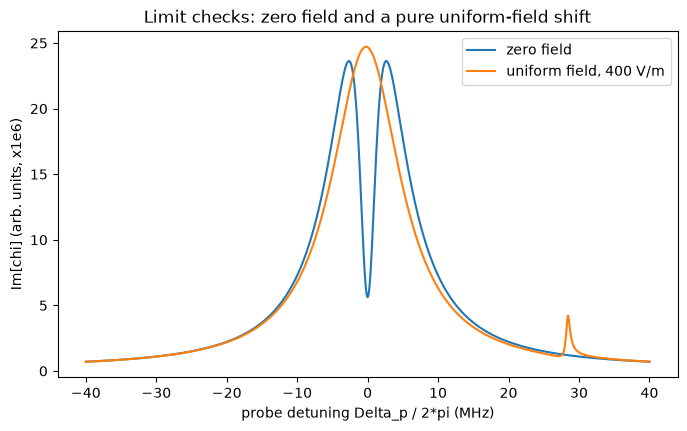

**Zero field byte-identical to the unperturbed line:** True  
**Uniform field:** a pure translation of the same lineshape, checked byte-identical against a direct single-atom evaluation at that one shift (`tests/test_rydberg_cell_response.py::TestC5LimitKillTests`).

In [8]:
n_atoms = 5
weights = np.ones(n_atoms)

zero_fields = np.zeros(n_atoms)
uniform_fields = np.full(n_atoms, 400.0)

spec_zero = rcr.compose_inhomogeneous_eit_spectrum(
    delta_p,
    zero_fields,
    weights,
    rcr.RB85_32D52_ALPHA0_AU,
    n_star,
    system,
    e_coupling_v_per_m=e_coupling,
)
spec_uniform = rcr.compose_inhomogeneous_eit_spectrum(
    delta_p,
    uniform_fields,
    weights,
    rcr.RB85_32D52_ALPHA0_AU,
    n_star,
    system,
    e_coupling_v_per_m=e_coupling,
)
baseline = rcr.doppler_averaged_susceptibility(
    delta_p, 0.0, 0.0, 1.0, e_coupling, 0.0, system, 320.0, rcr.RB85_MASS_KG, n_velocity_points=33
)  # n_velocity_points=33 matches compose_inhomogeneous_eit_spectrum's own default

fig, ax = plt.subplots()
ax.plot(delta_p / (2 * math.pi) / 1e6, spec_zero.imag * 1e6, label="zero field")
ax.plot(delta_p / (2 * math.pi) / 1e6, spec_uniform.imag * 1e6, label="uniform field, 400 V/m")
ax.set_xlabel("probe detuning Delta_p / 2*pi (MHz)")
ax.set_ylabel("Im[chi] (arb. units, x1e6)")
ax.legend()
ax.set_title("Limit checks: zero field and a pure uniform-field shift")
plt.show()

display(
    Markdown(
        "**Zero field byte-identical to the unperturbed line:** "
        f"{bool(np.array_equal(spec_zero, baseline))}  \n"
        "**Uniform field:** a pure translation of the same lineshape, checked byte-identical "
        "against a direct single-atom evaluation at that one shift "
        "(`tests/test_rydberg_cell_response.py::TestC5LimitKillTests`)."
    )
)

## 7. The surface-charge demonstrator (C6)

Visible light photoionizes a thin condensed alkali layer on a vapor
cell's glass wall, leaving patches of positive surface charge (Patrick
et al. 2025, arXiv:2502.07018). Those patches distort the local field
the Rydberg atoms sit in, shifting and asymmetrically broadening the
EIT/AT line, worse for a smaller cell where the atoms sit closer to the
walls. A superposition of point-charge Coulomb fields models this
wall-patch field in closed form over a cylindrical cell, since no
finite-difference electrostatics solver exists in this codebase to
reuse. Composing many atoms' resulting spectra the same way section 6
did reproduces the qualitative shift-and-broadening signature above.


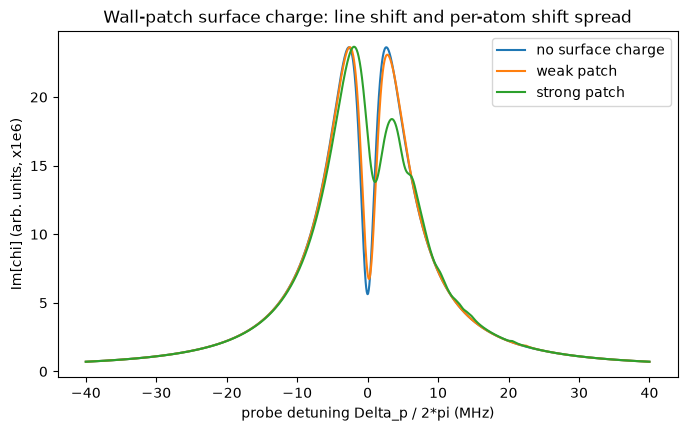

**Per-atom Stark-shift spread, no charge:** 0.0000 MHz  
**weak patch:** 2.8270 MHz  
**strong patch:** 45.2322 MHz  

The spread of per-atom Stark shifts grows with patch charge, the mechanism behind the observed line's asymmetric broadening. **Classification: computable_comparison** (Patrick et al. 2025 give no printed numeric target for this specific quantity; the check is qualitative phenomenology, not an arithmetic reproduction of a published number).

In [9]:
rng = np.random.default_rng(20260902)
cell_radius_m = 0.0125  # Patrick et al. 2025's own 25 mm cell diameter
cell_length_m = 0.078  # their own 78 mm cell length
n_atoms_demo = 60
positions = rcr.cylindrical_cell_atom_positions(cell_radius_m, cell_length_m, n_atoms_demo, rng)


def demo_spectrum(patch_charge_c, radius_m, atom_positions):
    patches = [
        rcr.WallPatch(position_m=np.array([radius_m, 0.0, 0.0]), charge_c=patch_charge_c),
        rcr.WallPatch(position_m=np.array([-radius_m, 0.0, 0.0]), charge_c=patch_charge_c),
    ]
    fields = np.array([np.linalg.norm(rcr.patch_field_v_per_m(p, patches)) for p in atom_positions])
    weights = np.ones(len(atom_positions))
    spec = rcr.compose_inhomogeneous_eit_spectrum(
        delta_p,
        fields,
        weights,
        rcr.RB85_32D52_ALPHA0_AU,
        n_star,
        system,
        e_coupling_v_per_m=e_coupling,
    )
    return spec, fields


spec_none, fields_none = demo_spectrum(0.0, cell_radius_m, positions)
spec_weak, fields_weak = demo_spectrum(1.0e-12, cell_radius_m, positions)
spec_strong, fields_strong = demo_spectrum(4.0e-12, cell_radius_m, positions)

fig, ax = plt.subplots()
ax.plot(delta_p / (2 * math.pi) / 1e6, spec_none.imag * 1e6, label="no surface charge")
ax.plot(delta_p / (2 * math.pi) / 1e6, spec_weak.imag * 1e6, label="weak patch")
ax.plot(delta_p / (2 * math.pi) / 1e6, spec_strong.imag * 1e6, label="strong patch")
ax.set_xlabel("probe detuning Delta_p / 2*pi (MHz)")
ax.set_ylabel("Im[chi] (arb. units, x1e6)")
ax.legend()
ax.set_title("Wall-patch surface charge: line shift and per-atom shift spread")
plt.show()


def shift_spread_mhz(field_values):
    shifts = [
        rcr.rydberg_quadratic_stark_shift_hz(rcr.RB85_32D52_ALPHA0_AU, f, n_star)
        for f in field_values
    ]
    return np.std(shifts) / 1e6


spread_none = shift_spread_mhz(fields_none)
spread_weak = shift_spread_mhz(fields_weak)
spread_strong = shift_spread_mhz(fields_strong)

display(
    Markdown(
        f"**Per-atom Stark-shift spread, no charge:** {spread_none:.4f} MHz  \n"
        f"**weak patch:** {spread_weak:.4f} MHz  \n"
        f"**strong patch:** {spread_strong:.4f} MHz  \n\n"
        "The spread of per-atom Stark shifts grows with patch charge, the mechanism "
        "behind the observed line's asymmetric broadening. **Classification: "
        "computable_comparison** (Patrick et al. 2025 give no printed numeric target "
        "for this specific quantity; the check is qualitative phenomenology, not an "
        "arithmetic reproduction of a published number)."
    )
)

In [10]:
small_positions = rcr.cylindrical_cell_atom_positions(0.006, cell_length_m, n_atoms_demo, rng)
_, fields_small = demo_spectrum(4.0e-12, 0.006, small_positions)
spread_small = shift_spread_mhz(fields_small)
spread_baseline = shift_spread_mhz(fields_strong)

display(
    Markdown(
        f"**Per-atom shift spread, strong patch, 25 mm cell:** {spread_baseline:.4f} MHz  \n"
        f"**Per-atom shift spread, strong patch, 12 mm cell:** {spread_small:.4f} MHz  \n\n"
        "The spread grows again as the cell shrinks and the atoms sit closer to the "
        "charged walls, the same trend Patrick et al. 2025 report between their own "
        "long-axis and short-axis measurement paths."
    )
)

**Per-atom shift spread, strong patch, 25 mm cell:** 45.2322 MHz  
**Per-atom shift spread, strong patch, 12 mm cell:** 78.0424 MHz  

The spread grows again as the cell shrinks and the atoms sit closer to the charged walls, the same trend Patrick et al. 2025 report between their own long-axis and short-axis measurement paths.

## 8. Where this leaves the field

The surface-charge distortion problem is current and unresolved. A 2025-2026
literature search found no paper claiming it solved or a mitigation protocol
standardized field-wide; partial, geometry-specific workarounds are appearing
(all-dielectric wafer-level cells, MEMS cells with passivated cavities,
near-infrared three-photon excitation schemes that avoid the visible light
driving the photoionization in the first place), and none of them is a general
fix. A lab building a Rydberg RF sensor today can use this chain to explore
how much cell geometry and excitation-wavelength choices are likely to matter
before committing to a design, from published inputs.

**Scope.** This is Phase A: the quadratic (isolated-state) Stark regime,
scalar polarizability only, one calibration ladder (Rb-85,
32D5/2-33P3/2). Full Stark-map diagonalization beyond the quadratic
regime, tensor polarizability, differentiability, and coupling to
external EM field exports for the cell and waveguide side are later
work.
